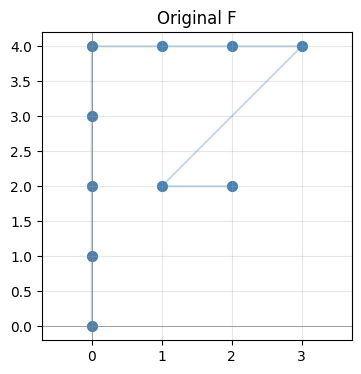

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# "F" hərfini təşkil edən nöqtələr (2D)
points = np.array([
    # Şaquli xətt (sol)
    [0, 0], [0, 1], [0, 2], [0, 3], [0, 4],
    # Üst üfüqi xətt
    [1, 4], [2, 4], [3, 4],
    # Orta üfüqi xətt
    [1, 2], [2, 2],
]).T# shape: (2, N) — hər sütun bir nöqtə

def plot_points(pts, title, color='steelblue'):
    plt.figure(figsize=(4, 4))
    plt.scatter(pts[0], pts[1], c=color, s=50)
    plt.plot(pts[0], pts[1], c=color, alpha=0.3)
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.axis('equal')
    plt.show()

plot_points(points, "Original F")

True


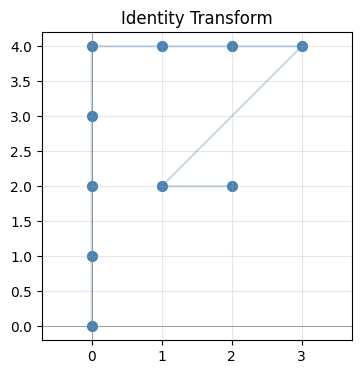

In [8]:
# Transformasiya 1 — Identity
A_identity = np.array([[1, 0], [0, 1]])

# (a) Loop üsulu
result_loop = np.zeros_like(points)  # eyni ölçüdə boş matris

for i in range(points.shape[1]):       # hər nöqtə üçün
    result_loop[:, i] = A_identity @ points[:, i]

# (b) A @ points üsulu
result_matrix = A_identity @ points

# Eyni olduğunu yoxla
print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır

# Qrafik
plot_points(result_matrix, "Identity Transform")

True


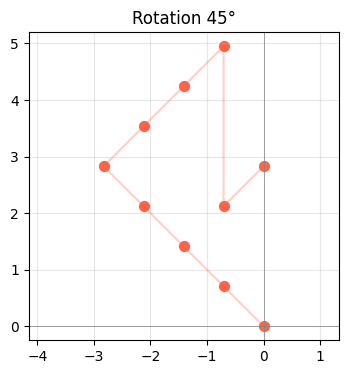

In [11]:
# Transformasiya 2 — Rotation 45°
theta = np.radians(45)

A_rotation = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# (a) Loop üsulu
result_loop = np.zeros_like(points, dtype=float) # Python-da dəyişənlər əvvəlki dəyəri saxlayır buna gore dtype=float istifade edirik

for i in range(points.shape[1]):
    result_loop[:, i] = A_rotation @ points[:, i]

# (b) A @ points üsulu
result_matrix = A_rotation @ points

# Eyni olduğunu yoxla
print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır

# Qrafik
plot_points(result_matrix, "Rotation 45°", color='tomato')

True


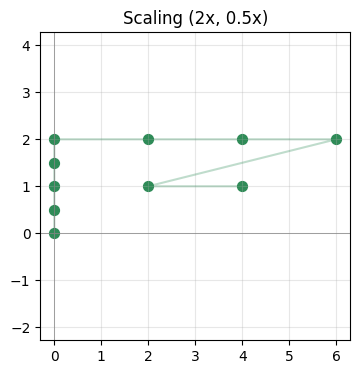

In [24]:
A_scaling = np.array([[2,0],[0, 0.5]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_scaling @ points[:, i]

result_matrix = A_scaling @ points

print(np.allclose(result_loop, result_matrix))  # True çıxmalıdır
plot_points(result_matrix, "Scaling (2x, 0.5x)", color='seagreen')


True


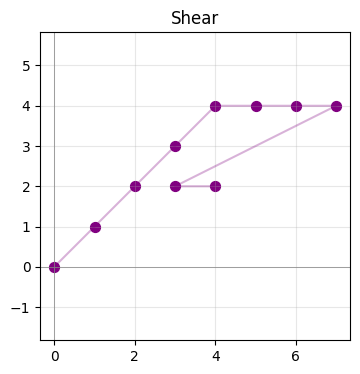

In [15]:
A_shear = np.array([[1, 1],[0, 1]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_shear @ points[:, i]

result_matrix = A_shear @ points

print(np.allclose(result_loop, result_matrix))
plot_points(result_matrix, "Shear", color='purple')

True


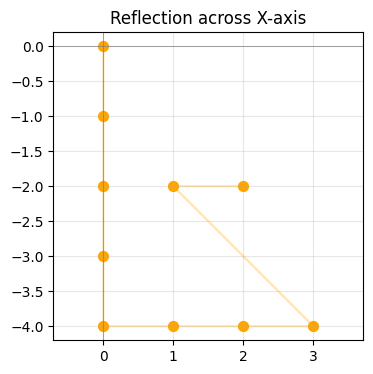

In [16]:
A_reflection = np.array([[1, 0], [0, -1]])

result_loop = np.zeros_like(points, dtype=float)
for i in range(points.shape[1]):
    result_loop[:, i] = A_reflection @ points[:, i]

result_matrix = A_reflection @ points

print(np.allclose(result_loop, result_matrix))
plot_points(result_matrix, "Reflection across X-axis", color='orange')

In [ ]:
# İki transformasiyanın sırasının yoxlanılması:
R = A_rotation   
S = A_scaling    

RS = R @ S
SR = S @ R

print("R @ S:\n", RS)
print("S @ R:\n", SR)
print("Eynidir?", np.allclose(RS, SR))  # False çıxmalıdır

R @ S:
 [[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]
S @ R:
 [[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]
Eynidir? False


In [19]:
# İki rotation matrisinin kommutativ olub olmadığını yoxlanılması:

R1 = A_rotation
theta2 = np.radians(30)

R2 = np.array([
    [np.cos(theta2), -np.sin(theta2)],
    [np.sin(theta2),  np.cos(theta2)]
])

print("R1 @ R2:\n", R1 @ R2)
print("R2 @ R1:\n", R2 @ R1)
print("Eynidir?", np.allclose(R1 @ R2, R2 @ R1))  # True çıxmalıdır



R1 @ R2:
 [[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]
R2 @ R1:
 [[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]
Eynidir? True
